In [ ]:
print("SMS Spam Detection Project")
print("Project setup successful!")

SMS Spam Detection Project
Project setup successful!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving SMSSpamCollection to SMSSpamCollection


In [4]:
print(uploaded.keys())

dict_keys(['SMSSpamCollection'])


In [5]:
import os

for file in uploaded.keys():
    print("Filename:", file)
    print("Size:", os.path.getsize(file), "bytes")

Filename: SMSSpamCollection
Size: 477907 bytes


In [6]:
import pandas as pd

df = pd.read_csv(
    "SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print(df.head())
print("\nDataset shape:", df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset shape: (5572, 2)


In [7]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
print(df.isnull().sum())

label      0
message    0
dtype: int64


In [9]:
df["label"] = df["label"].map({"ham": 0, "spam": 1})

print(df.head())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...


In [10]:
X = df["message"]
y = df["label"]

print("Messages:", len(X))
print("Labels:", len(y))

Messages: 5572
Labels: 5572


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (4457, 5000)
Testing data shape: (1115, 5000)


In [13]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train_tfidf, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9721973094170404
Accuracy percentage: 97.22 %


In [15]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Ham", "Spam"]
))

              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



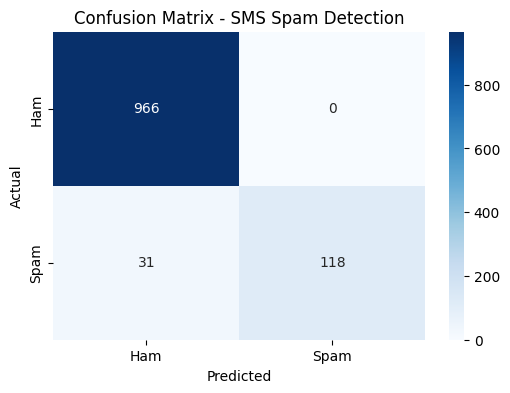

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SMS Spam Detection")
plt.show()


In [24]:
def predict_sms(message):
    message_tfidf = vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]

    if prediction == 1:
        return "SPAM 🚨"
    else:
        return "NOT SPAM ✅"


test_message = input("Enter an SMS message: ")

print("Prediction:", predict_sms(test_message))

Enter an SMS message: i will call you later
Prediction: NOT SPAM ✅


In [25]:
import os

print("Model exists:", os.path.exists("spam_model.pkl"))
print("Vectorizer exists:", os.path.exists("tfidf_vectorizer.pkl"))

Model exists: True
Vectorizer exists: True


In [26]:
import joblib

model = joblib.load("spam_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Model and vectorizer loaded successfully!")

Model and vectorizer loaded successfully!


In [28]:
from google.colab import files

files.download("spam_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
%%writefile app.py

import streamlit as st
import joblib

# Load the trained model and vectorizer
model = joblib.load("spam_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

st.title("📱 SMS Spam Detection")
st.write("Enter an SMS message to check whether it is Spam or Not Spam.")

message = st.text_area("Enter your SMS message:")

if st.button("Predict"):
    if message.strip() == "":
        st.warning("Please enter an SMS message.")
    else:
        message_tfidf = vectorizer.transform([message])
        prediction = model.predict(message_tfidf)[0]

        if prediction == 1:
            st.error("🚨 SPAM MESSAGE")
        else:
            st.success("✅ NOT SPAM")

Writing app.py


In [31]:
import os

print(os.path.exists("app.py"))

True


In [32]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.5 MB/s eta 0:00:00


In [33]:
!streamlit --version

Streamlit, version 1.65.0


In [34]:
!streamlit run app.py &>/content/logs.txt &

import time
time.sleep(5)

print("Streamlit app started!")

Streamlit app started!


In [35]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [36]:
from google.colab import output

output.serve_kernel_port_as_iframe(8501)

<IPython.core.display.Javascript object>

In [37]:
print(open("/content/logs.txt").read())



2026-10-04 07:17:26.283 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.229.223.57:8501

2026-10-04 07:19:00.782 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:19:02.975 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:19:05.448 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8

In [38]:
print(open("/content/logs.txt").read()[-3000:])

t header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:21:01.496 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:21:10.084 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:21:17.162 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:21:27.643 Rejecting WebSocket connection w

In [39]:
!pkill -f streamlit

In [40]:
!streamlit run app.py --server.port 8501 > /content/logs.txt 2>&1 &

In [41]:
!tail -20 /content/logs.txt

2026-10-04 07:25:09.877 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:25:13.924 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:25:18.499 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-user-runtimes.internal:8007
2026-10-04 07:25:23.781 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usw1c2-1me209ttlvfxb-c.us-west1-2.prod.colab.dev, host=m-s-kkb-usw1c2-1me209ttlvfxb.us-west1-c.c.codatalab-

In [42]:
!pkill -f streamlit

In [43]:
!streamlit run app.py --server.port 8501 --server.address 0.0.0.0 --server.enableXsrfProtection false --server.enableCORS false > /content/logs.txt 2>&1 &

In [44]:
!tail -20 /content/logs.txt



2026-10-04 07:28:29.886 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://8.229.223.57:8501



In [45]:
%%writefile requirements.txt
pandas
scikit-learn
joblib
streamlit
matplotlib
seaborn

Writing requirements.txt


In [46]:
print(open("requirements.txt").read())

pandas
scikit-learn
joblib
streamlit
matplotlib
seaborn



In [47]:
%%writefile .gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
.env

Writing .gitignore


In [48]:
print(open(".gitignore").read())

__pycache__/
*.pyc
.ipynb_checkpoints/
.env



In [49]:
%%writefile README.md

# 📱 SMS Spam Detection using Machine Learning

## 📌 Project Overview

SMS Spam Detection is a machine learning project that classifies SMS messages as either **Spam** or **Not Spam**. The system uses Natural Language Processing (NLP) techniques to convert text messages into numerical features and a Multinomial Naive Bayes classifier to perform the classification.

The project provides an interactive Streamlit interface where users can enter an SMS message and receive a prediction.

## 🎯 Objectives

- Detect unwanted and potentially fraudulent SMS messages.
- Apply NLP techniques to text data.
- Convert SMS text into numerical features using TF-IDF.
- Train a machine learning classification model.
- Evaluate the model using standard performance metrics.
- Provide an easy-to-use interface for SMS prediction.

## 🛠️ Technologies Used

- Python
- Pandas
- Scikit-learn
- TF-IDF
- Multinomial Naive Bayes
- Streamlit
- Matplotlib
- Seaborn
- Joblib

## 📊 Dataset

The project uses the **SMS Spam Collection dataset**, containing 5,572 SMS messages labelled as either:

- **Ham** – normal SMS messages
- **Spam** – unwanted SMS messages

## 🔄 Methodology

```text
SMS Dataset
     ↓
Data Preprocessing
     ↓
Train-Test Split
     ↓
TF-IDF Feature Extraction
     ↓
Multinomial Naive Bayes
     ↓
Model Evaluation
     ↓
Spam / Not Spam Prediction

Writing README.md


In [50]:
import os

files = [
    "app.py",
    "SMS_Spam_Detection.ipynb",
    "spam_model.pkl",
    "tfidf_vectorizer.pkl",
    "requirements.txt",
    "README.md",
    ".gitignore"
]

for file in files:
    print(file, "→", "✅ Found" if os.path.exists(file) else "❌ Missing")

app.py → ✅ Found
SMS_Spam_Detection.ipynb → ❌ Missing
spam_model.pkl → ✅ Found
tfidf_vectorizer.pkl → ✅ Found
requirements.txt → ✅ Found
README.md → ✅ Found
.gitignore → ✅ Found
